In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, kruskal, chi2_contingency, fisher_exact
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Загрузка данных

In [5]:
df = pd.read_csv('immunology_dataset.csv')
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nСтруктура данных:\n{df.info()}")
print(f"\nПервые 5 строк:\n{df.head()}")

Размер датасета: 100 строк, 9 столбцов
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Group           100 non-null    str    
 1   Gender          100 non-null    str    
 2   Age             100 non-null    int64  
 3   BMI             100 non-null    float64
 4   IL6_expression  100 non-null    float64
 5   TNF_expression  100 non-null    float64
 6   CRP             100 non-null    float64
 7   WBC             100 non-null    float64
 8   Autoantibodies  100 non-null    int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 7.2 KB

Структура данных:
None

Первые 5 строк:
        Group Gender  Age   BMI  IL6_expression  TNF_expression   CRP   WBC  \
0      Cancer      M   52  24.3           14.55            2.30   4.7  10.4   
1  Autoimmune      F   21  22.6           10.75           18.85  20.1   8.1   
2     Healthy      F   42  24.8       

Проверка количественных переменных на нормальность

Age: W=0.9884, p=0.5382, Normal=Yes
BMI: W=0.9947, p=0.9652, Normal=Yes
IL6_expression: W=0.9141, p=0.0000, Normal=No
TNF_expression: W=0.9166, p=0.0000, Normal=No
CRP: W=0.6452, p=0.0000, Normal=No
WBC: W=0.9817, p=0.1785, Normal=Yes


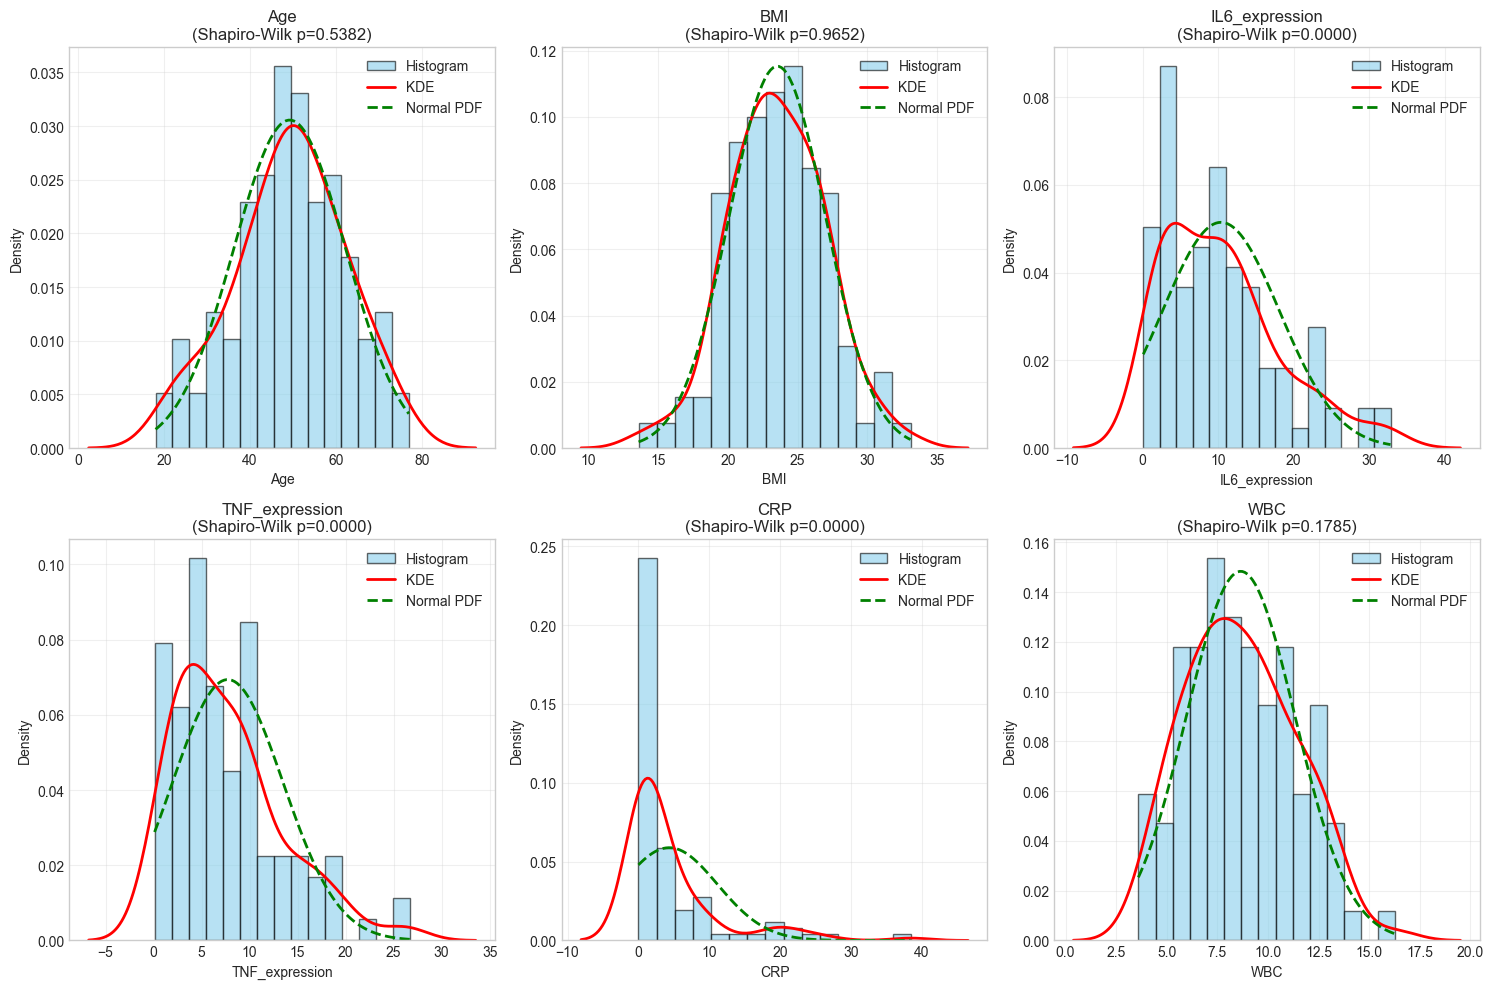

In [ ]:
quantitative_vars = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']

normality_results = []
for var in quantitative_vars:
    stat, p_value = shapiro(df[var])
    is_normal = p_value > 0.05
    normality_results.append({
        'Variable': var,
        'W_statistic': round(stat, 4),
        'p_value': round(p_value, 4),
        'Normal': 'Yes' if is_normal else 'No'
    })
    print(f"{var}: W={stat:.4f}, p={p_value:.4f}, Normal={'Yes' if is_normal else 'No'}")

normality_df = pd.DataFrame(normality_results)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, var in enumerate(quantitative_vars):
    ax = axes[idx]
    
    ax.hist(df[var], bins=15, density=True, alpha=0.6, color='skyblue', 
            edgecolor='black', label='Histogram')
    
    sns.kdeplot(df[var], ax=ax, color='red', linewidth=2, label='KDE')
    
    mu, sigma = df[var].mean(), df[var].std()
    x = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'g--', linewidth=2, label='Normal PDF')
    
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.set_title(f'{var}\n(Shapiro-Wilk p={normality_df[normality_df["Variable"]==var]["p_value"].values[0]:.4f})')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('pdf_plots.png', dpi=300, bbox_inches='tight')
plt.show()

Диаграммы рассеяния

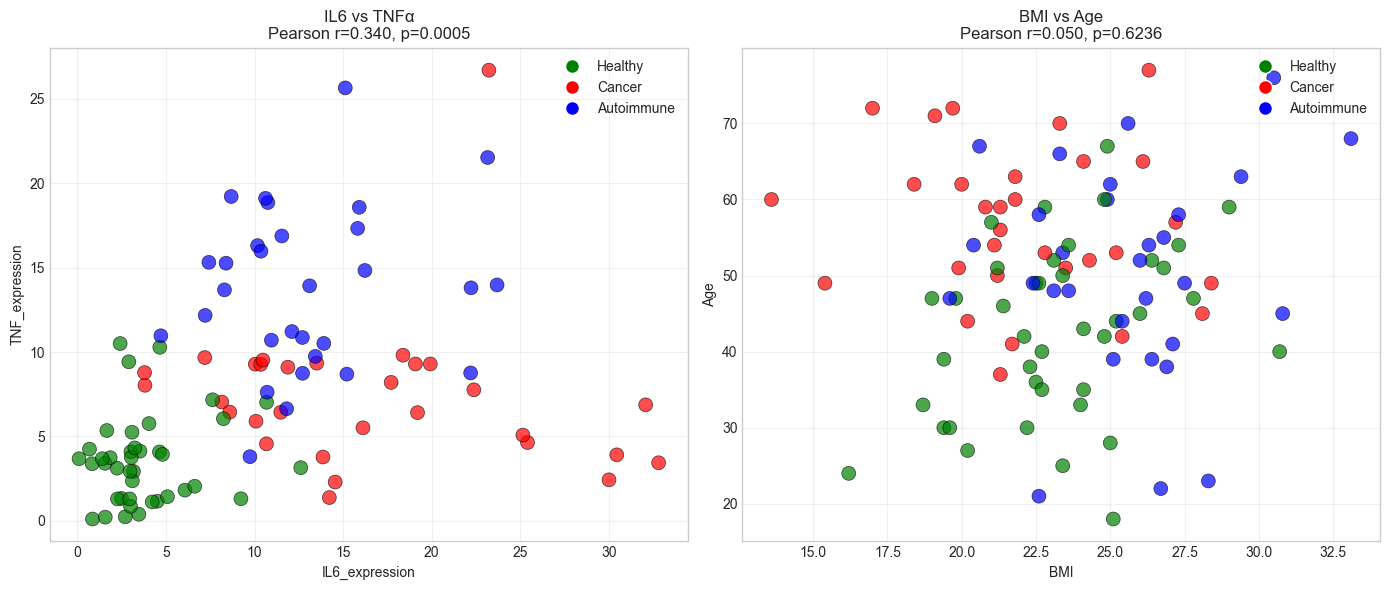

IL6 vs TNF: Pearson r = 0.340, p = 0.0005
BMI vs Age: Pearson r = 0.050, p = 0.6236


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
scatter1 = ax1.scatter(df['IL6_expression'], df['TNF_expression'], 
                       c=df['Group'].map({'Healthy': 'green', 'Cancer': 'red', 'Autoimmune': 'blue'}),
                       alpha=0.7, s=100, edgecolors='black', linewidth=0.5)

corr_il6_tnf, p_il6_tnf = stats.pearsonr(df['IL6_expression'], df['TNF_expression'])
ax1.set_xlabel('IL6_expression')
ax1.set_ylabel('TNF_expression')
ax1.set_title(f'IL6 vs TNFα\nPearson r={corr_il6_tnf:.3f}, p={p_il6_tnf:.4f}')
ax1.grid(alpha=0.3)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10)]
ax1.legend(handles, ['Healthy', 'Cancer', 'Autoimmune'], loc='upper right')

ax2 = axes[1]
scatter2 = ax2.scatter(df['BMI'], df['Age'], 
                       c=df['Group'].map({'Healthy': 'green', 'Cancer': 'red', 'Autoimmune': 'blue'}),
                       alpha=0.7, s=100, edgecolors='black', linewidth=0.5)

corr_bmi_age, p_bmi_age = stats.pearsonr(df['BMI'], df['Age'])
ax2.set_xlabel('BMI')
ax2.set_ylabel('Age')
ax2.set_title(f'BMI vs Age\nPearson r={corr_bmi_age:.3f}, p={p_bmi_age:.4f}')
ax2.grid(alpha=0.3)
ax2.legend(handles, ['Healthy', 'Cancer', 'Autoimmune'], loc='upper right')

plt.tight_layout()
# plt.savefig('scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"IL6 vs TNF: Pearson r = {corr_il6_tnf:.3f}, p = {p_il6_tnf:.4f}")
print(f"BMI vs Age: Pearson r = {corr_bmi_age:.3f}, p = {p_bmi_age:.4f}")

Тепловая карта матрицы корреляций для количественных переменных

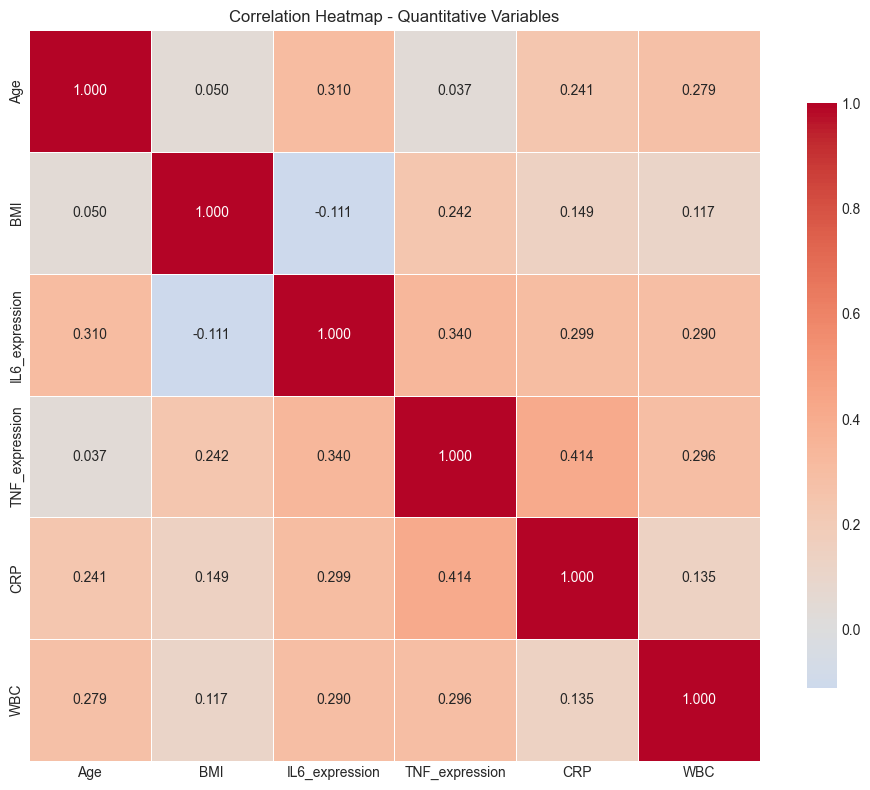


Матрица корреляций:
                  Age    BMI  IL6_expression  TNF_expression    CRP    WBC
Age             1.000  0.050           0.310           0.037  0.241  0.279
BMI             0.050  1.000          -0.111           0.242  0.149  0.117
IL6_expression  0.310 -0.111           1.000           0.340  0.299  0.290
TNF_expression  0.037  0.242           0.340           1.000  0.414  0.296
CRP             0.241  0.149           0.299           0.414  1.000  0.135
WBC             0.279  0.117           0.290           0.296  0.135  1.000

--------------------------------------------------------------------------------
ПАРЫ С ЗАМЕТНОЙ КОРРЕЛЯЦИЕЙ (|r| > 0.3):
--------------------------------------------------------------------------------
Age ↔ IL6_expression: r = 0.310 (positive)
IL6_expression ↔ TNF_expression: r = 0.340 (positive)
TNF_expression ↔ CRP: r = 0.414 (positive)


In [ ]:
corr_matrix = df[quantitative_vars].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Quantitative Variables')
plt.tight_layout()
# plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nМатрица корреляций:")
print(corr_matrix.round(3))

print("\n" + "-" * 80)
print("ПАРЫ С ЗАМЕТНОЙ КОРРЕЛЯЦИЕЙ (|r| > 0.3):")
print("-" * 80)

strong_correlations = []
for i in range(len(quantitative_vars)):
    for j in range(i+1, len(quantitative_vars)):
        var1 = quantitative_vars[i]
        var2 = quantitative_vars[j]
        r = corr_matrix.loc[var1, var2]
        if abs(r) > 0.3:
            direction = "positive" if r > 0 else "negative"
            strong_correlations.append((var1, var2, r, direction))
            print(f"{var1} ↔ {var2}: r = {r:.3f} ({direction})")

Корреляция IL6 и TNF по группам

In [9]:
group_correlations = []
for group in df['Group'].unique():
    group_data = df[df['Group'] == group]
    r, p = stats.pearsonr(group_data['IL6_expression'], group_data['TNF_expression'])
    group_correlations.append({
        'Group': group,
        'n': len(group_data),
        'Pearson_r': round(r, 3),
        'p_value': round(p, 4),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })
    print(f"{group} (n={len(group_data)}): r = {r:.3f}, p = {p:.4f}, Significant={'Yes' if p < 0.05 else 'No'}")

Cancer (n=30): r = -0.103, p = 0.5889, Significant=No
Autoimmune (n=30): r = 0.134, p = 0.4801, Significant=No
Healthy (n=40): r = 0.137, p = 0.3993, Significant=No


Сравнение IL6: Healthy vs Cancer


Healthy: n=40, mean=3.83, std=2.71, median=3.06
Cancer:  n=30, mean=16.49, std=8.21, median=14.39

Тест Манна-Уитни: U=52.00, p=0.0000
Статистически значимое различие: Да


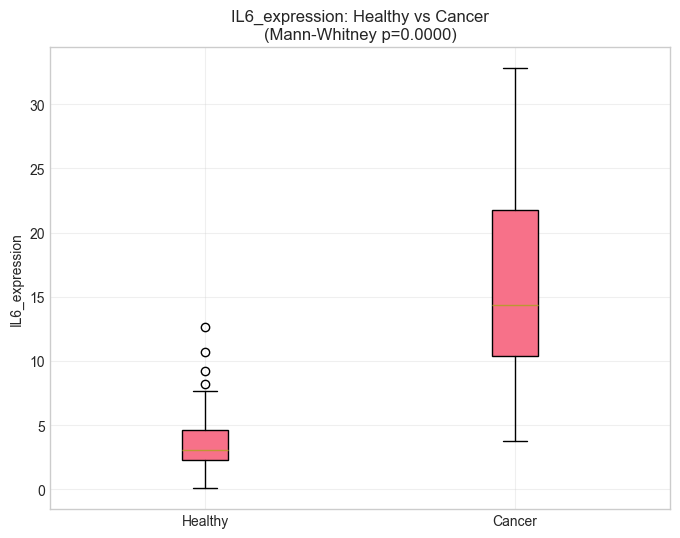

In [ ]:
healthy_il6 = df[df['Group'] == 'Healthy']['IL6_expression']
cancer_il6 = df[df['Group'] == 'Cancer']['IL6_expression']

print(f"\nHealthy: n={len(healthy_il6)}, mean={healthy_il6.mean():.2f}, std={healthy_il6.std():.2f}, median={healthy_il6.median():.2f}")
print(f"Cancer:  n={len(cancer_il6)}, mean={cancer_il6.mean():.2f}, std={cancer_il6.std():.2f}, median={cancer_il6.median():.2f}")

u_stat, p_il6 = mannwhitneyu(healthy_il6, cancer_il6, alternative='two-sided')
print(f"\nТест Манна-Уитни: U={u_stat:.2f}, p={p_il6:.4f}")
print(f"Статистически значимое различие: {'Да' if p_il6 < 0.05 else 'Нет'}")

plt.figure(figsize=(8, 6))
plt.boxplot([healthy_il6, cancer_il6], labels=['Healthy', 'Cancer'], patch_artist=True)
plt.ylabel('IL6_expression')
plt.title(f'IL6_expression: Healthy vs Cancer\n(Mann-Whitney p={p_il6:.4f})')
plt.grid(alpha=0.3)
# plt.savefig('il6_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Сравнение возраста между группами


Описательная статистика:
Healthy: n=40, mean=42.70, std=11.35
Cancer: n=30, mean=56.70, std=10.11
Autoimmune: n=30, mean=50.53, std=13.72

Проверка нормальности по группам:
Healthy: Shapiro-Wilk p=0.9386
Cancer: Shapiro-Wilk p=0.9035
Autoimmune: Shapiro-Wilk p=0.3378

ANOVA: F=12.38, p=0.0000

Post-hoc тест Tukey:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2 meandiff p-adj   lower    upper  reject
----------------------------------------------------------
Autoimmune  Cancer   6.1667 0.1107  -1.0675 13.4008  False
Autoimmune Healthy  -7.8333  0.019 -14.6003 -1.0664   True
    Cancer Healthy    -14.0    0.0 -20.7669 -7.2331   True
----------------------------------------------------------


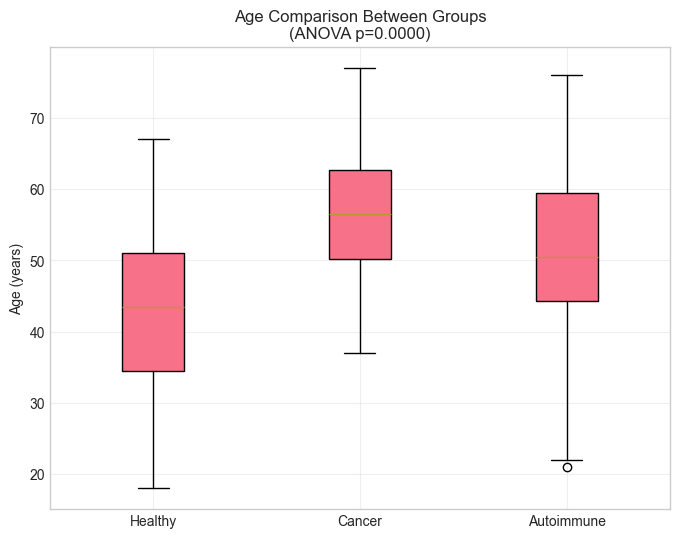

In [ ]:
age_groups = [df[df['Group'] == g]['Age'] for g in ['Healthy', 'Cancer', 'Autoimmune']]

print("\nОписательная статистика:")
for group in ['Healthy', 'Cancer', 'Autoimmune']:
    group_age = df[df['Group'] == group]['Age']
    print(f"{group}: n={len(group_age)}, mean={group_age.mean():.2f}, std={group_age.std():.2f}")

print("\nПроверка нормальности по группам:")
for group in ['Healthy', 'Cancer', 'Autoimmune']:
    stat, p = shapiro(df[df['Group'] == group]['Age'])
    print(f"{group}: Shapiro-Wilk p={p:.4f}")

f_stat, p_age = stats.f_oneway(*age_groups)
print(f"\nANOVA: F={f_stat:.2f}, p={p_age:.4f}")

if p_age < 0.05:
    all_ages = df['Age'].values
    all_groups = df['Group'].values
    tukey = pairwise_tukeyhsd(all_ages, all_groups)
    print("\nPost-hoc тест Tukey:")
    print(tukey)

plt.figure(figsize=(8, 6))
plt.boxplot(age_groups, labels=['Healthy', 'Cancer', 'Autoimmune'], patch_artist=True)
plt.ylabel('Age (years)')
plt.title(f'Age Comparison Between Groups\n(ANOVA p={p_age:.4f})')
plt.grid(alpha=0.3)
# plt.savefig('age_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Сравнение CRP: Autoimmune vs Healthy


Healthy:     n=40, mean=0.68, std=0.57, median=0.50
Autoimmune:  n=30, mean=8.67, std=9.42, median=4.50

Тест Манна-Уитни (односторонний): U=1069.00, p=0.0000
CRP значимо выше в группе Autoimmune: Да


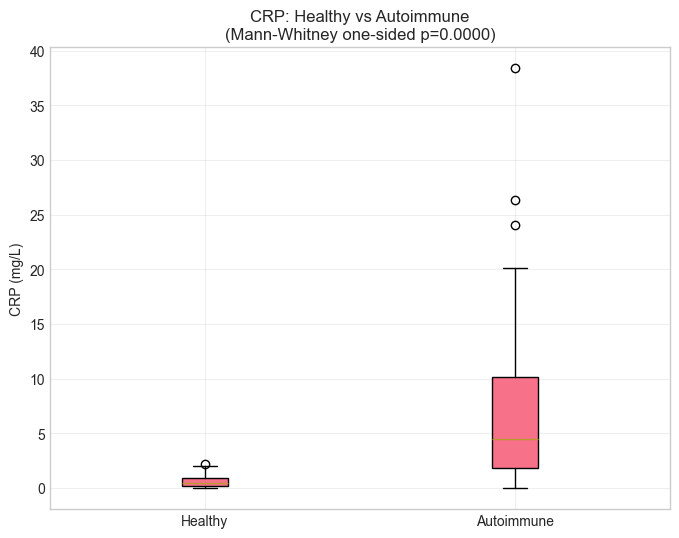

In [ ]:
autoimmune_crp = df[df['Group'] == 'Autoimmune']['CRP']
healthy_crp = df[df['Group'] == 'Healthy']['CRP']

print(f"\nHealthy:     n={len(healthy_crp)}, mean={healthy_crp.mean():.2f}, std={healthy_crp.std():.2f}, median={healthy_crp.median():.2f}")
print(f"Autoimmune:  n={len(autoimmune_crp)}, mean={autoimmune_crp.mean():.2f}, std={autoimmune_crp.std():.2f}, median={autoimmune_crp.median():.2f}")

u_stat, p_crp_one_sided = mannwhitneyu(autoimmune_crp, healthy_crp, alternative='greater')
print(f"\nТест Манна-Уитни (односторонний): U={u_stat:.2f}, p={p_crp_one_sided:.4f}")
print(f"CRP значимо выше в группе Autoimmune: {'Да' if p_crp_one_sided < 0.05 else 'Нет'}")

plt.figure(figsize=(8, 6))
plt.boxplot([healthy_crp, autoimmune_crp], labels=['Healthy', 'Autoimmune'], patch_artist=True)
plt.ylabel('CRP (mg/L)')
plt.title(f'CRP: Healthy vs Autoimmune\n(Mann-Whitney one-sided p={p_crp_one_sided:.4f})')
plt.grid(alpha=0.3)
# plt.savefig('crp_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Связь между группой и наличием аутоантител

In [13]:
contingency_table = pd.crosstab(df['Group'], df['Autoantibodies'])
print("\nТаблица сопряжённости:")
print(contingency_table)

print("\nПроцент пациентов с аутоантителами по группам:")
for group in df['Group'].unique():
    group_data = df[df['Group'] == group]
    pct = (group_data['Autoantibodies'] == 1).sum() / len(group_data) * 100
    print(f"{group}: {pct:.1f}%")

chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-square тест: χ²={chi2:.2f}, df={dof}, p={p_chi2:.4f}")
print(f"Статистически значимая связь: {'Да' if p_chi2 < 0.05 else 'Нет'}")


Таблица сопряжённости:
Autoantibodies   0   1
Group                 
Autoimmune       7  23
Cancer          23   7
Healthy         33   7

Процент пациентов с аутоантителами по группам:
Cancer: 23.3%
Autoimmune: 76.7%
Healthy: 17.5%

Chi-square тест: χ²=29.18, df=2, p=0.0000
Статистически значимая связь: Да


Связь между полом и наличием аутоантител в группе аутоимунных заболеваний

In [14]:
autoimmune_df = df[df['Group'] == 'Autoimmune']
contingency_gender = pd.crosstab(autoimmune_df['Gender'], autoimmune_df['Autoantibodies'])
print("\nТаблица сопряжённости:")
print(contingency_gender)

print("\nПроцент с аутоантителами по полу:")
for gender in ['M', 'F']:
    gender_data = autoimmune_df[autoimmune_df['Gender'] == gender]
    if len(gender_data) > 0:
        pct = (gender_data['Autoantibodies'] == 1).sum() / len(gender_data) * 100
        print(f"{gender}: {pct:.1f}% (n={len(gender_data)})")

try:
    odds_ratio, p_fisher = fisher_exact(contingency_gender, alternative='two-sided')
    print(f"\nТочный тест Фишера: odds_ratio={odds_ratio:.2f}, p={p_fisher:.4f}")
    print(f"Статистически значимая связь: {'Да' if p_fisher < 0.05 else 'Нет'}")
except:
    print("\nНе удалось выполнить тест Фишера (возможно, нулевые значения в таблице)")


Таблица сопряжённости:
Autoantibodies  0   1
Gender               
F               7  15
M               0   8

Процент с аутоантителами по полу:
M: 100.0% (n=8)
F: 68.2% (n=22)

Точный тест Фишера: odds_ratio=inf, p=0.1434
Статистически значимая связь: Нет


Сравнение переменных: Autoimmune vs Cancer

Variable             Autoimmune      Cancer          p-value      Significant 
--------------------------------------------------------------------------------
Age                  50.53           56.70           0.0522       No          
BMI                  25.56           22.01           0.0001       Yes         
IL6_expression       12.96           16.49           0.1335       No          
TNF_expression       13.68           7.34            0.0000       Yes         
CRP                  8.67            4.91            0.1535       No          
WBC                  9.81            9.67            0.8387       No          


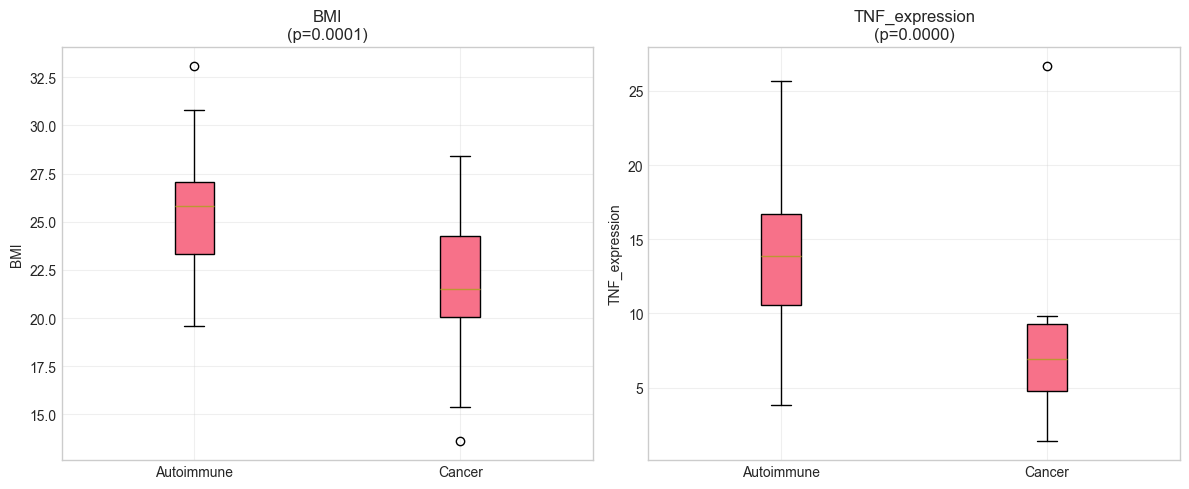


Статистически значимо отличаются: BMI, TNF_expression


In [ ]:
compare_vars = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']
comparison_results = []

print(f"{'Variable':<20} {'Autoimmune':<15} {'Cancer':<15} {'p-value':<12} {'Significant':<12}")
print("-" * 80)

for var in compare_vars:
    autoimmune_var = df[df['Group'] == 'Autoimmune'][var]
    cancer_var = df[df['Group'] == 'Cancer'][var]
    
    _, p_norm1 = shapiro(autoimmune_var)
    _, p_norm2 = shapiro(cancer_var)
    
    if p_norm1 > 0.05 and p_norm2 > 0.05:
        t_stat, p_val = stats.ttest_ind(autoimmune_var, cancer_var)
        test_used = 't-test'
    else:
        u_stat, p_val = mannwhitneyu(autoimmune_var, cancer_var, alternative='two-sided')
        test_used = 'Mann-Whitney'
    
    significant = 'Yes' if p_val < 0.05 else 'No'
    comparison_results.append({
        'Variable': var,
        'Autoimmune_mean': round(autoimmune_var.mean(), 2),
        'Cancer_mean': round(cancer_var.mean(), 2),
        'p_value': round(p_val, 4),
        'Significant': significant,
        'Test': test_used
    })
    
    print(f"{var:<20} {autoimmune_var.mean():<15.2f} {cancer_var.mean():<15.2f} {p_val:<12.4f} {significant:<12}")

significant_vars = [r['Variable'] for r in comparison_results if r['Significant'] == 'Yes']

if significant_vars:
    fig, axes = plt.subplots(1, len(significant_vars), figsize=(6*len(significant_vars), 5))
    if len(significant_vars) == 1:
        axes = [axes]
    
    for idx, var in enumerate(significant_vars):
        autoimmune_var = df[df['Group'] == 'Autoimmune'][var]
        cancer_var = df[df['Group'] == 'Cancer'][var]
        
        axes[idx].boxplot([autoimmune_var, cancer_var], labels=['Autoimmune', 'Cancer'], patch_artist=True)
        axes[idx].set_ylabel(var)
        p_val = [r['p_value'] for r in comparison_results if r['Variable'] == var][0]
        axes[idx].set_title(f'{var}\n(p={p_val:.4f})')
        axes[idx].grid(alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig('autoimmune_vs_cancer.png', dpi=300, bbox_inches='tight')
    plt.show()

print(f"\nСтатистически значимо отличаются: {', '.join(significant_vars) if significant_vars else 'Нет переменных'}")